# Base de Dados Escolhida para Estudo:
Ocorrências Aeronáuticas - ANAC
https://dados.gov.br/dados/conjuntos-dados/ocorrencias-aeronauticas

# Metadados:
https://www.anac.gov.br/acesso-a-informacao/dados-abertos/areas-de-atuacao/seguranca-operacional/ocorrencias-aeronauticas/76-ocorrencias-aeronauticas

# Dados Auxiliares
PDF: MCA 3-6 - Manual de Investigação do SIPAER
https://www2.fab.mil.br/cenipa/index.php/anexos/24-legsipaer

IDH:


# Descrição dos Atributos da Base de Dados
Campo:-									Descrição  
Número da Ocorrência:-					Número da Ocorrência Aeronáutica  
Classificação da Ocorrência:-			Classificação da Ocorrência Aeronáutica  
Data da Ocorrência:-					Data (UTC) da Ocorrência Aeronáutica  
Hora da Ocorrência:-					Hora (UTC) da Ocorrência Aeronáutica  
Município:-								Município do local da Ocorrência, quando aplicável  
UF:-									UF do local da Ocorrência, quando aplicável  
Latitude:-								Latitude do local onde houve a ocorrência  
Longitude:-								Longitude do local onde houve a ocorrência  
Tipo de Aeródromo:-						Tipo de Aeródromo em que houve a ocorrência, quando aplicável.  
​Histórico:-								Descrição sobre a ocorrência  
Matrícula:-								Matrícula da Aeronave associada à Ocorrência Aeronáutica  
Categoria da Aeronave:-					Categoria da Aeronave associada à Ocorrência Aeronáutica  
Operador:-								Operador da Aeronave associada à Ocorrência Aeronáutica  
Tipo de Ocorrência:-					Tipo de Ocorrência de acordo com a taxonomia ADREP  
Fase da Operação:-						Fase da Operação da Aeronave quando da Ocorrência Aeronáutica  
Operação:-								Tipo de Operação da Aeronave no momento da Ocorrência Aeronáutica  
Danos à Aeronave:-						Danos à Aeronave associada à Ocorrência Aeronáutica  
Aeródromo de Destino:-					Indicador de Localidade ICAO do Aeródromo de Destino da Aeronave associada à Ocorrência Aeronáutica  
Aeródromo de Origem:-					Indicador de Localidade ICAO do Aeródromo de Origem da Aeronave associada à Ocorrência Aeronáutica  
Lesões Fatais - Tripulantes:-			Número de Tripulantes com lesões fatais na Aeronave associada à Ocorrência Aeronáutica  
Lesões Fatais – Passageiros:-			Número de Passageiros com lesões fatais na Aeronave associada à Ocorrência Aeronáutica  
Lesões Fatais - Terceiros:-				Número de Terceiros com lesões fatais causadas pela Aeronave associada à Ocorrência Aeronáutica  
Lesões Graves – Tripulantes:-			Número de Tripulantes com lesões graves na Aeronave associada à Ocorrência Aeronáutica  
Lesões Graves – Passageiros:-			Número de Passageiros com lesões graves na Aeronave associada à Ocorrência Aeronáutica  
Lesões Graves – Terceiros:-				Número de Terceiros com lesões graves causadas pela Aeronave associada à Ocorrência Aeronáutica  
Lesões Leves - Tripulantes:-			Número de Tripulantes com lesões leves na Aeronave associada à Ocorrência Aeronáutica  
Lesões Leves – Passageiros:-			Número de Passageiros com lesões leves na Aeronave associada à Ocorrência Aeronáutica  
Lesões Leves - Terceiros:-				Número de Terceiros com lesões leves causadas pela Aeronave associada à Ocorrência Aeronáutica  
Ilesos – Tripulantes:-					Número de Tripulantes ilesos na Aeronave associada à Ocorrência Aeronáutica  
Ilesos – Passageiros:-					Número de Passageiros ilesos na Aeronave associada à Ocorrência Aeronáutica  
Lesões Desconhecidas – Tripulantes:-	Número de Tripulantes com lesões desconhecida na Aeronave associada à Ocorrência Aeronáutica  
Lesões Desconhecidas – Passageiros:-	Número de Passageiros com lesões desconhecida na Aeronave associada à Ocorrência Aeronáutica  
Lesões Desconhecidas - Terceiros:-		Número de Terceiros com lesões desconhecida causadas pela Aeronave associada à Ocorrência Aeronáutica  
PSSO:-									A ocorrência é considerada nos indicadores do Programa de Supervisão da Segurança Operacional (PSSO)  
Número da Ficha:-						Número da ficha cadastrada pelo CENIPA para a ocorrência.  
Operador Padronizado:-					Nome do operador/empresa, padronizado pelo sistema, responsável pela aeronave na época da ocorrência.  
Região:-								Região do País relacionada ao campo UF.  
ICAO:-									Código ICAO do aeródromo onde houve a ocorrência.  
Modelo:-								Descrição do Modelo da Aeronave  
CLS:-									Código que identifica o tipo da aeronave.  
Tipo ICAO:-								Código de identificação da aeronave segundo a ICAO.  
PMD:-									Peso máximo de Decolagem da aeronave  
Número de Assentos:-					Quantidade de assentos disponíveis na aeronave.  
Nome do Fabricante:-					Nome da empresa fabricante da aeronave.  
​Descrição Tipo:-						Descrição do tipo da ocorrência​  


# Recorte Temporal do Estudo
ano inicial:  
ano final:  
motivo:  

# Quais as Perguntas  
1- Quais os 3 tipos mais comuns de ocorrência por estado?  
2- Qual a média de ocorrências por região por ano?  
3- Quais fases das operações geram mais acidentes?  
4- Qual o total de fatalidades por operação por ano?  
5- Qual o tipo mais comum de ocorrência por categoria da aeronave?  
6- Qual a categoria de aeronave com menor indice de fatalidades? (total de fatalidades / total de ocorrências / número de acentos*)  
*normalização para comparação com demais aeronaves

# Importando Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import requests
from io import StringIO

# Importando a base de dados do GitHub

In [ ]:
def carregar_csv_github(url_raw: str, sep: str = ",", skiprows: int = 0) -> pd.DataFrame:
    """
    Baixa um CSV público do GitHub e retorna como DataFrame pandas adaptável.
    """
    response = requests.get(url_raw, timeout=30)
    response.raise_for_status()

    # Lê o arquivo aplicando as configurações passadas nos argumentos
    df_lido = pd.read_csv(
        StringIO(response.text),
        sep=sep,
        skiprows=skiprows,
        on_bad_lines='skip'
    )

    # Transforma a string textual 'null' no valor NaN real do sistema
    df_limpo = df_lido.replace('null', np.nan)

    return df_limpo

# ==============================================================
# CARREGANDO E EXIBINDO A BASE DO CENIPA (Ocorrências)
# ==============================================================
csv_path_cenipa = "https://raw.githubusercontent.com/Jobanu/Projeto-Final-DS-PY-004/main/Dados/V_OCORRENCIA_AMPLA.csv"

# Carrega usando vírgula (sep=",") e sem pular linhas (skiprows=0)
df = carregar_csv_github(csv_path_cenipa, sep=";", skiprows=1)

print(f"--- BASE CENIPA: Carregadas {len(df)} ocorrências ---")
display(df.head())


# ==============================================================
# CARREGANDO E EXIBINDO A BASE DO IDH
# ==============================================================
csv_path_idhm = "https://raw.githubusercontent.com/Jobanu/Projeto-Final-DS-PY-004/desenvolvimento/Dados/IDHM.csv"

# Carrega usando ponto e vírgula (sep=";") e pulando a primeira linha (skiprows=1)
df_idhm = carregar_csv_github(csv_path_idhm, sep=";", skiprows=0)

print(f"\n--- BASE IDH: Carregadas {len(df_idhm)} linhas de estados ---")
display(df_idhm.head())


--- BASE CENIPA: Carregadas 5021 ocorrências ---


,Numero_da_Ocorrencia,Numero_da_Ficha,Operador_Padronizado,Classificacao_da_Ocorrencia,Data_da_Ocorrencia,Hora_da_Ocorrencia,Municipio,UF,Regiao,Descricao_do_Tipo,...,Lesoes_Desconhecidas_Tripulantes,Lesoes_Desconhecidas_Passageiros,Lesoes_Desconhecidas_Terceiros,Modelo,CLS,Tipo_ICAO,PMD,Numero_de_Assentos,Nome_do_Fabricante,PSSO
0,36746,2023765949,NITZ AVIACAO AGRICOLA LTDA. - EPP,Acidente,2023-03-23,11:20:00,PASSO DO SOBRADO,RS,Sul,EXCURSÃO DE PISTA,...,NaN,NaN,NaN,A188B,L1P,C188,1497.0,1.0,CESSNA AIRCRAFT,verdadeiro
1,38381,202385892466,ENOCK RESENDE JUNIOR,Acidente,2023-07-09,16:00:00,SANTANA DO RIACHO,MG,Sudeste,OUTROS,...,NaN,NaN,NaN,H2,G1P,ZZZZ,500.0,2.0,ENOCK RESENDE JUNIOR,verdadeiro
2,36409,2023525502,MS ARMAZENS GERAIS LTDA.,Incidente Grave,2023-02-16,19:00:00,TAILÂNDIA,PA,Norte,COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO,...,NaN,NaN,NaN,SR22,L1P,SR22,1542.0,4.0,CIRRUS DESIGN,verdadeiro
3,31607,2022464840,ADRIANO AUGUSTO PECLAT DE PAULA,Incidente Grave,2022-03-27,13:50,PIRENÓPOLIS,GO,Centro-Oeste,EXCURSÃO DE PISTA,...,NaN,NaN,NaN,PA-28R-201T,L1P,P28R,1315.0,4.0,PIPER AIRCRAFT,verdadeiro
4,31607,2022464840,ANTONIO PAULO MACHADO GONTIJO,Incidente Grave,2022-03-27,13:50,PIRENÓPOLIS,GO,Centro-Oeste,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,...,NaN,NaN,NaN,PA-28R-201T,L1P,P28R,1315.0,4.0,PIPER AIRCRAFT,verdadeiro



--- BASE IDH: Carregadas 28 linhas de estados ---


,Territorialidades,IDHM 2012,Faixa_de_IDHM,IDHM 2013,Faixa_de_IDHM.1,IDHM 2014,Faixa_de_IDHM.2,IDHM 2015,Faixa_de_IDHM.3,IDHM 2016,...,IDHM 2020,Faixa_de_IDHM.8,IDHM 2021,Faixa_de_IDHM.9,IDHM 2022,Faixa_de_IDHM.10,IDHM 2023,Faixa_de_IDHM.11,IDHM 2024,Faixa_de_IDHM.12
0,BR,0.744,Alto,0.752,Alto,0.760,Alto,0.762,Alto,0.767,...,0.776,Alto,0.757,Alto,0.788,Alto,0.798,Alto,0.805,Muito Alto
1,AC,0.705,Alto,0.709,Alto,0.719,Alto,0.719,Alto,0.723,...,0.736,Alto,0.702,Alto,0.732,Alto,0.740,Alto,0.754,Alto
2,AL,0.657,Medio,0.653,Medio,0.670,Medio,0.669,Medio,0.680,...,0.694,Medio,0.691,Medio,0.722,Alto,0.739,Alto,0.746,Alto
3,AP,0.709,Alto,0.735,Alto,0.726,Alto,0.728,Alto,0.732,...,0.707,Alto,0.681,Medio,0.743,Alto,0.767,Alto,0.759,Alto
4,AM,0.706,Alto,0.717,Alto,0.720,Alto,0.724,Alto,0.723,...,0.725,Alto,0.700,Alto,0.757,Alto,0.764,Alto,0.767,Alto


In [ ]:
tamanho_df_inicio = len(df)
print(f"Tamanho inicial do DataFrame: {tamanho_df_inicio}")
memoria_df_inicio = df.memory_usage(deep=True).sum()
print(f"Tamanho inicial do DataFrame bytes: {memoria_df_inicio}")

Tamanho inicial do DataFrame: 5021
Tamanho inicial do DataFrame bytes: 10733212


# Explorando a base de dados

In [ ]:
# Dimensões
df.shape

(5021, 45)

In [ ]:
# Visualizando as 5 primeiras linhas
df.head()

,Numero_da_Ocorrencia,Numero_da_Ficha,Operador_Padronizado,Classificacao_da_Ocorrencia,Data_da_Ocorrencia,Hora_da_Ocorrencia,Municipio,UF,Regiao,Descricao_do_Tipo,...,Lesoes_Desconhecidas_Tripulantes,Lesoes_Desconhecidas_Passageiros,Lesoes_Desconhecidas_Terceiros,Modelo,CLS,Tipo_ICAO,PMD,Numero_de_Assentos,Nome_do_Fabricante,PSSO
0,36746,2023765949,NITZ AVIACAO AGRICOLA LTDA. - EPP,Acidente,2023-03-23,11:20:00,PASSO DO SOBRADO,RS,Sul,EXCURSÃO DE PISTA,...,NaN,NaN,NaN,A188B,L1P,C188,1497.0,1.0,CESSNA AIRCRAFT,verdadeiro
1,38381,202385892466,ENOCK RESENDE JUNIOR,Acidente,2023-07-09,16:00:00,SANTANA DO RIACHO,MG,Sudeste,OUTROS,...,NaN,NaN,NaN,H2,G1P,ZZZZ,500.0,2.0,ENOCK RESENDE JUNIOR,verdadeiro
2,36409,2023525502,MS ARMAZENS GERAIS LTDA.,Incidente Grave,2023-02-16,19:00:00,TAILÂNDIA,PA,Norte,COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO,...,NaN,NaN,NaN,SR22,L1P,SR22,1542.0,4.0,CIRRUS DESIGN,verdadeiro
3,31607,2022464840,ADRIANO AUGUSTO PECLAT DE PAULA,Incidente Grave,2022-03-27,13:50,PIRENÓPOLIS,GO,Centro-Oeste,EXCURSÃO DE PISTA,...,NaN,NaN,NaN,PA-28R-201T,L1P,P28R,1315.0,4.0,PIPER AIRCRAFT,verdadeiro
4,31607,2022464840,ANTONIO PAULO MACHADO GONTIJO,Incidente Grave,2022-03-27,13:50,PIRENÓPOLIS,GO,Centro-Oeste,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,...,NaN,NaN,NaN,PA-28R-201T,L1P,P28R,1315.0,4.0,PIPER AIRCRAFT,verdadeiro


In [ ]:
# Visualizando as 5 últimas linhas
df.tail()

,Numero_da_Ocorrencia,Numero_da_Ficha,Operador_Padronizado,Classificacao_da_Ocorrencia,Data_da_Ocorrencia,Hora_da_Ocorrencia,Municipio,UF,Regiao,Descricao_do_Tipo,...,Lesoes_Desconhecidas_Tripulantes,Lesoes_Desconhecidas_Passageiros,Lesoes_Desconhecidas_Terceiros,Modelo,CLS,Tipo_ICAO,PMD,Numero_de_Assentos,Nome_do_Fabricante,PSSO
5016,11300,200511226153045,LUG TAXI AEREO,Incidente Grave,2005-11-22,01:20:00,PIRACICABA,SP,Sudeste,COLISÃO COM AVE,...,0.0,0.0,0.0,EMB-820C CARAJA,L2T,PAT4,3629.0,8.0,EMBRAER,verdadeiro
5017,11280,PT-WOF 05MAI2020 20H46 SERIPA2,CASA CIVIL,Incidente Grave,2020-05-05,20:46:00,FORTALEZA,CE,Nordeste,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,...,0.0,0.0,0.0,B200,L2T,BE20,5670.0,10.0,BEECH AIRCRAFT,verdadeiro
5018,26249,202084338,PLA &amp; SILVA AVIACAO AGRICOLA LTDA,Acidente,2020-12-06,13:30,SANTA VITÓRIA DO PALMAR,RS,Sul,COMBUSTÍVEL,...,NaN,NaN,NaN,EMB-202,L1P,IPAN,1800.0,1.0,EMBRAER,verdadeiro
5019,11277,PU-DGH 21ABR2020 18H00 SERIPA3,AG ESCOLA DE AVIACAO LEVE LTDA,Acidente,2020-04-21,18:00:00,JAGUARÉ,ES,Sudeste,MANOBRA ABRUPTA,...,0.0,0.0,0.0,BRAVO700,L1P,ULAC,600.0,2.0,AEROBRAVO INDÚSTRIA AERONÁUTICA LTDA,verdadeiro
5020,11277,PU-DGH 21ABR2020 18H00 SERIPA3,AG ESCOLA DE AVIACAO LEVE LTDA,Acidente,2020-04-21,18:00:00,JAGUARÉ,ES,Sudeste,PERDA DE CONTROLE EM VOO,...,0.0,0.0,0.0,BRAVO700,L1P,ULAC,600.0,2.0,AEROBRAVO INDÚSTRIA AERONÁUTICA LTDA,verdadeiro


In [ ]:
# Visualizando os Metadados do Dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5021 entries, 0 to 5020
Data columns (total 45 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Numero_da_Ocorrencia              5021 non-null   int64  
 1   Numero_da_Ficha                   5019 non-null   object 
 2   Operador_Padronizado              4945 non-null   object 
 3   Classificacao_da_Ocorrencia       5021 non-null   object 
 4   Data_da_Ocorrencia                5021 non-null   object 
 5   Hora_da_Ocorrencia                3588 non-null   object 
 6   Municipio                         3627 non-null   object 
 7   UF                                5018 non-null   object 
 8   Regiao                            4351 non-null   object 
 9   Descricao_do_Tipo                 4379 non-null   object 
 10  ICAO                              1687 non-null   object 
 11  Latitude                          3531 non-null   object 
 12  Longit

Atributos de [Data_da_Ocorrencia] e [Hora_da_Ocorrencia] carregados como object, é necessário ajustar este carregamento no comando de leitura do .csv:  
 4   Data_da_Ocorrencia                5021 non-null   object   
 5   Hora_da_Ocorrencia                3588 non-null   object  

 45 Colunas disponíveis. Será necessário selecionar as colunas próprias para o estudo, uma vez que fica inviável tratar todos dados nulls, vazios, outliners e depois não usar esses dados para o estudo.  
   

Será Necessário tratamento com cruzamento deste dados para preencimento do que for possível:  
Municipio                           1394  
UF                                     3  
Regiao                               670  

# Calculando NaN na Base de Dados Crua

In [ ]:
def calcular_nan_por_atributo(df_NaN: pd.DataFrame) -> pd.DataFrame:
  # Calcula o número de valores NaN para cada coluna
  nan_counts = df_NaN.isnull().sum()

  # Calcula o total de registros no DataFrame
  total_records = len(df_NaN)

  # Cria um DataFrame com a contagem de NaN
  df_nan_analysis = pd.DataFrame({
      'Atributo': nan_counts.index,
      'NaN_Contagem': nan_counts.values
  })

  # Calcula o percentual de NaN's
  df_nan_analysis['NaN_Percentual'] = (df_nan_analysis['NaN_Contagem'] / total_records) * 100
  return df_nan_analysis

# Execução do código
df_nan_analysis = calcular_nan_por_atributo(df)
display(df_nan_analysis)

,Atributo,NaN_Contagem,NaN_Percentual
0,Numero_da_Ocorrencia,0,0.000000
1,Numero_da_Ficha,2,0.039833
2,Operador_Padronizado,76,1.513643
3,Classificacao_da_Ocorrencia,0,0.000000
4,Data_da_Ocorrencia,0,0.000000
5,Hora_da_Ocorrencia,1433,28.540131
6,Municipio,1394,27.763394
7,UF,3,0.059749
8,Regiao,670,13.343955
9,Descricao_do_Tipo,642,12.786298


In [ ]:
df[df['UF'].isnull()][['UF', 'Historico']]

,UF,Historico
3766,NaN,Aircraft landed on RWY 24 and shortly after ma...
4705,NaN,A aeronave decolou do Aeródromo Formosa (SWFR)...
4928,NaN,"During cruise between WPT 0524N and KODOS, at ..."


É possível inferir que o atributo UF do ID 4705 é GO, os demais podem ser excluídos para o estudo de acidentes no território nacional, uma vez que, pelo histórico, ocorreram fora do território nacional.

In [ ]:
df[df['Regiao'].isnull()][['UF', 'Historico']]

,UF,Historico
131,Exterior,"Immediately after take-off, with adverse meteo..."
132,Exterior,"Immediately after take-off, with adverse meteo..."
137,Exterior,A aeronave teve problemas no motor nº 1 durant...
369,Indeterminado,NaN
402,Indeterminado,"A aeronave decolou de local não registrado, co..."
...,...,...
4705,NaN,A aeronave decolou do Aeródromo Formosa (SWFR)...
4715,Exterior,Confidence Rating: Information is only availab...
4716,Exterior,Seaplane flooded during landing. Cockpit and f...
4851,Exterior,The Aircraft took off from Hong Kong Internati...


Podemos Excluir os registros com atributos [UF] == Exterior, uma vez que se trata de ocorrências fora do território nacional e, portanto, fora do range deste estudo que se restringe as ocorrências em território nacional.  
Podemos Excluir os registros com atributos [UF] == Indeterminado e [Histórico] == NaN, pois não dá para determinar o Estado da ocorrência para o estudo.  
Os demais Indeterminados, podem ser inferidos pelo histórico, mas devemos considerar o custo de uma Machine Learning para extrair esta informação ou fazer manualmente um a um.

Após o tratamento, devemos fazer a correlação [UF] x [Regiao] para preencher os dados faltantes de [Regiao] atráves dos dados existentes de [UF]

# Filtros do Estudo
1 - [Numero_da_Ocorrencia] (tratando como indice)  
2 - [Classificacao_da_Ocorrencia]? 'Acidente' e/ou 'Incidente Grave'  
3 - Período do estudo baseado em [Data_da_Ocorrencia]  (Quais anos?)  
# Atributos de Interesse para as perguntas
1- agrupar por([UF]); contar([Tipo_de_Ocorrencia]); <-corresponde([Descricao_do_Tipo]); filtra(ano([Data_da_Ocorrencia]))  
  
2- agrupar por [Regiao]; agrupar por ano([Data_da_Ocorrencia]); média(soma([Lesoes_Fatais_Tripulantes]) soma([Lesoes_Fatais_Passageiros]) soma([Lesoes_Fatais_Terceiros]))  
  
3- agrupar por [Fase_da_Operacao]; contar([Numero_da_Ocorrencia])  
  
4- agrupar por [Fase_da_Operacao]; soma(soma([Lesoes_Fatais_Tripulantes]) soma([Lesoes_Fatais_Passageiros]) soma([Lesoes_Fatais_Terceiros])  
  
5- agrupar por [Categoria_da_Aeronave]; agrupar por [Tipo_de_Ocorrencia]. contar([Numero_da_Ocorrencia])  

6- agrupar por [Categoria_da_Aeronave]; 	soma(soma([Lesoes_Fatais_Tripulantes]) soma([Lesoes_Fatais_Passageiros]) soma([Lesoes_Fatais_Terceiros]) /
										contagem([Numero_da_Ocorrencia]) /
										soma([Numero_de_Assentos])


In [ ]:
Atritubos_interesse = [
    'Numero_da_Ocorrencia',
    'Classificacao_da_Ocorrencia',
    'Data_da_Ocorrencia',
    'Historico',
    'UF',
    'Regiao',
    'Tipo_de_Ocorrencia',
    'Descricao_do_Tipo',
    'Operacao',
    'Lesoes_Fatais_Tripulantes',
    'Lesoes_Fatais_Passageiros',
    'Lesoes_Fatais_Terceiros',
    'Lesoes_Graves_Tripulantes',
    'Lesoes_Graves_Passageiros',
    'Lesoes_Graves_Terceiros',
    'Lesoes_Leves_Tripulantes',
    'Lesoes_Leves_Passageiros',
    'Lesoes_Leves_Terceiros',
    'Ilesos_Tripulantes',
    'Ilesos_Passageiros',
    'Lesoes_Desconhecidas_Tripulantes',
    'Lesoes_Desconhecidas_Passageiros',
    'Lesoes_Desconhecidas_Terceiros',
    'Fase_da_Operacao',
    'Categoria_da_Aeronave',
    'Numero_de_Assentos'
    ]

Será necessário estudar o forma de preencher os dados Nulls nestes Atributos, pois são atributos de interesse no estudo:  
Lesoes_Fatais_Tripulantes           1118  
Lesoes_Fatais_Passageiros           1239  
Lesoes_Fatais_Terceiros             1319  
Lesoes_Graves_Tripulantes           1168  
Lesoes_Graves_Passageiros           1281  
Lesoes_Graves_Terceiros             1327  
Lesoes_Leves_Tripulantes            1124  
Lesoes_Leves_Passageiros            1277  
Lesoes_Leves_Terceiros              1327  
Ilesos_Tripulantes                   410  
Ilesos_Passageiros                   949  
Lesoes_Desconhecidas_Tripulantes    1315  
Lesoes_Desconhecidas_Passageiros    1326  
Lesoes_Desconhecidas_Terceiros      1327  

In [ ]:
# 1. Lista com as colunas de lesões e contagem da base
colunas_lesoes = [
    'Lesoes_Fatais_Tripulantes', 'Lesoes_Fatais_Passageiros', 'Lesoes_Fatais_Terceiros',
    'Lesoes_Graves_Tripulantes', 'Lesoes_Graves_Passageiros', 'Lesoes_Graves_Terceiros',
    'Lesoes_Leves_Tripulantes', 'Lesoes_Leves_Passageiros', 'Lesoes_Leves_Terceiros',
    'Ilesos_Tripulantes', 'Ilesos_Passageiros',
    'Lesoes_Desconhecidas_Tripulantes', 'Lesoes_Desconhecidas_Passageiros', 'Lesoes_Desconhecidas_Terceiros'
]

df[colunas_lesoes].head(10)

,Lesoes_Fatais_Tripulantes,Lesoes_Fatais_Passageiros,Lesoes_Fatais_Terceiros,Lesoes_Graves_Tripulantes,Lesoes_Graves_Passageiros,Lesoes_Graves_Terceiros,Lesoes_Leves_Tripulantes,Lesoes_Leves_Passageiros,Lesoes_Leves_Terceiros,Ilesos_Tripulantes,Ilesos_Passageiros,Lesoes_Desconhecidas_Tripulantes,Lesoes_Desconhecidas_Passageiros,Lesoes_Desconhecidas_Terceiros
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,10.0,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,10.0,NaN,NaN,NaN


# Relendo o CSV com os novos filtros

In [ ]:
# Importando a base de dados do GitHub com filtros
def carregar_csv_github2(url_raw: str, pula_linha = 1) -> pd.DataFrame:
    """
    Baixa um CSV público do GitHub e retorna como DataFrame pandas.
    url_raw: Caminho no GitHub para o arquivo .CSV
    """
    response = requests.get(url_raw, timeout=30)
    response.raise_for_status()

    # 1. Lê o arquivo agora com somente os atributos de interesse
    # e com configuração de correta da [Data_da_Ocorrencia]
    df_lido = pd.read_csv(
        StringIO(response.text),
        sep=';',
        skiprows=pula_linha,
        on_bad_lines='skip',
        usecols=Atritubos_interesse,
        parse_dates=['Data_da_Ocorrencia']
    )

    # 2. Transforma a string textual 'null' no valor NaN real do sistema
    df_limpo = df_lido.replace('null', np.nan)

    # 3. Retorna o DataFrame perfeitamente estruturado
    return df_limpo

# Execução do código
df = carregar_csv_github2(csv_path)

print(f"Carregadas {len(df)} ocorrências")

NameError: name 'csv_path' is not defined

# Verificando as novas dimensões do Dataframe

In [ ]:
df.shape

(5021, 45)

In [ ]:
df.head()

,Numero_da_Ocorrencia,Numero_da_Ficha,Operador_Padronizado,Classificacao_da_Ocorrencia,Data_da_Ocorrencia,Hora_da_Ocorrencia,Municipio,UF,Regiao,Descricao_do_Tipo,...,Lesoes_Desconhecidas_Tripulantes,Lesoes_Desconhecidas_Passageiros,Lesoes_Desconhecidas_Terceiros,Modelo,CLS,Tipo_ICAO,PMD,Numero_de_Assentos,Nome_do_Fabricante,PSSO
0,36746,2023765949,NITZ AVIACAO AGRICOLA LTDA. - EPP,Acidente,2023-03-23,11:20:00,PASSO DO SOBRADO,RS,Sul,EXCURSÃO DE PISTA,...,NaN,NaN,NaN,A188B,L1P,C188,1497.0,1.0,CESSNA AIRCRAFT,verdadeiro
1,38381,202385892466,ENOCK RESENDE JUNIOR,Acidente,2023-07-09,16:00:00,SANTANA DO RIACHO,MG,Sudeste,OUTROS,...,NaN,NaN,NaN,H2,G1P,ZZZZ,500.0,2.0,ENOCK RESENDE JUNIOR,verdadeiro
2,36409,2023525502,MS ARMAZENS GERAIS LTDA.,Incidente Grave,2023-02-16,19:00:00,TAILÂNDIA,PA,Norte,COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO,...,NaN,NaN,NaN,SR22,L1P,SR22,1542.0,4.0,CIRRUS DESIGN,verdadeiro
3,31607,2022464840,ADRIANO AUGUSTO PECLAT DE PAULA,Incidente Grave,2022-03-27,13:50,PIRENÓPOLIS,GO,Centro-Oeste,EXCURSÃO DE PISTA,...,NaN,NaN,NaN,PA-28R-201T,L1P,P28R,1315.0,4.0,PIPER AIRCRAFT,verdadeiro
4,31607,2022464840,ANTONIO PAULO MACHADO GONTIJO,Incidente Grave,2022-03-27,13:50,PIRENÓPOLIS,GO,Centro-Oeste,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,...,NaN,NaN,NaN,PA-28R-201T,L1P,P28R,1315.0,4.0,PIPER AIRCRAFT,verdadeiro


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5021 entries, 0 to 5020
Data columns (total 45 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Numero_da_Ocorrencia              5021 non-null   int64  
 1   Numero_da_Ficha                   5019 non-null   object 
 2   Operador_Padronizado              4945 non-null   object 
 3   Classificacao_da_Ocorrencia       5021 non-null   object 
 4   Data_da_Ocorrencia                5021 non-null   object 
 5   Hora_da_Ocorrencia                3588 non-null   object 
 6   Municipio                         3627 non-null   object 
 7   UF                                5018 non-null   object 
 8   Regiao                            4351 non-null   object 
 9   Descricao_do_Tipo                 4379 non-null   object 
 10  ICAO                              1687 non-null   object 
 11  Latitude                          3531 non-null   object 
 12  Longit

In [ ]:
print(df.isna().sum())# Execução do código
df_nan_analysis_novo = calcular_nan_por_atributo(df)
display(df_nan_analysis_novo)

Numero_da_Ocorrencia                   0
Numero_da_Ficha                        2
Operador_Padronizado                  76
Classificacao_da_Ocorrencia            0
Data_da_Ocorrencia                     0
Hora_da_Ocorrencia                  1433
Municipio                           1394
UF                                     3
Regiao                               670
Descricao_do_Tipo                    642
ICAO                                3334
Latitude                            1490
Longitude                           1490
Tipo_de_Aerodromo                   3449
Historico                            265
Matricula                              4
Categoria_da_Aeronave                  9
Operador                              76
Tipo_de_Ocorrencia                   642
Fase_da_Operacao                    1300
Operacao                              94
Danos_a_Aeronave                    1426
Aerodromo_de_Destino                2138
Aerodromo_de_Origem                 2117
Lesoes_Fatais_Tr

,Atributo,NaN_Contagem,NaN_Percentual
0,Numero_da_Ocorrencia,0,0.000000
1,Numero_da_Ficha,2,0.039833
2,Operador_Padronizado,76,1.513643
3,Classificacao_da_Ocorrencia,0,0.000000
4,Data_da_Ocorrencia,0,0.000000
5,Hora_da_Ocorrencia,1433,28.540131
6,Municipio,1394,27.763394
7,UF,3,0.059749
8,Regiao,670,13.343955
9,Descricao_do_Tipo,642,12.786298


# Iniciando o tratamento dos Dados

## Lesões

## Tratamento das colunas dos tipos de Lesões - (NaN para 0)

A razão para escolhermos apenas as colunas de lesões e não o DataFrame inteiro é que o significado do "vazio" (NaN) muda completamente dependendo do tipo de dado da coluna. Substituir tudo por zero de forma automática geraria graves erros de lógica e distorções na análise.

1. Colunas de Texto (Strings) ficariam sem sentido

    - Operador: O responsável pelo voo passaria a se chamar 0 (o Pandas não saberia que ali deveria ser "Desconhecido")
    Matricula: O prefixo do avião viraria 0.

2. Colunas Numéricas Específicas seriam corrompidas, pois o número 0 possui um valor matemático real em engenharia aeronáutica.

    - PMD (Peso Máximo de Decolagem): Se uma aeronave experimental não teve o peso registrado, colocar 0 faria o Pandas calcular que o avião pesa zero quilos, o que estragaria qualquer média de peso que você tentasse fazer no projeto.
    - Numero_de_Assentos: Colocar 0 indicaria que o avião voava sem nenhum banco dentro, quando na verdade o dado apenas não foi coletado.

3. Nas colunas de Lesões, o 0 mantém a lógica perfeitaNas colunas de contagem de pessoas (Lesoes_Fatais, Lesoes_Graves), assumir que o vazio equivale a 0 é seguro e correto para o modelo de dados, pois:

    - Se o relatório não mencionou feridos, a hipótese estatística padrão é que zero pessoas se machucaram naquela categoria específica.
    - Permite converter a coluna de Float (número quebrado) para Int (número inteiro), já que não existem "1.5 pessoas mortas".

In [ ]:
# 1. Lista com as colunas de lesões e contagem da base
colunas_lesoes = [
    'Lesoes_Fatais_Tripulantes', 'Lesoes_Fatais_Passageiros', 'Lesoes_Fatais_Terceiros',
    'Lesoes_Graves_Tripulantes', 'Lesoes_Graves_Passageiros', 'Lesoes_Graves_Terceiros',
    'Lesoes_Leves_Tripulantes', 'Lesoes_Leves_Passageiros', 'Lesoes_Leves_Terceiros',
    'Ilesos_Tripulantes', 'Ilesos_Passageiros',
    'Lesoes_Desconhecidas_Tripulantes', 'Lesoes_Desconhecidas_Passageiros', 'Lesoes_Desconhecidas_Terceiros'
]

# --- ANTES ---
print("=== 1. QUANTIDADE DE NaNs ANTES DA LIMPEZA ===")
# Soma quantos NaNs existem apenas nas colunas da lista
print(df[colunas_lesoes].isna().sum())
print("-" * 50)


# 2. Criar a função de preenchimento
def preencher_nan_lesoes(dataframe: pd.DataFrame, lista_colunas: list) -> pd.DataFrame:
    """
    Substitui os valores NaN das colunas de lesões pelo número zero (0).
    Aplica a conversão para tipo inteiro (Int64), ideal para contagens.
    """
    # Faz uma cópia para não alterar o DataFrame original por acidente
    df_copia = dataframe.copy()

    # Preenche os NaNs com 0 e converte para tipo numérico inteiro
    df_copia[lista_colunas] = df_copia[lista_colunas].fillna(0).astype('int64')

    return df_copia


# 3. Aplicar a função no seu DataFrame
df = preencher_nan_lesoes(df, colunas_lesoes)


# --- DEPOIS ---
print("=== 2. QUANTIDADE DE NaNs DEPOIS DA LIMPEZA ===")
print(df[colunas_lesoes].isna().sum())
print("-" * 50)



=== 1. QUANTIDADE DE NaNs ANTES DA LIMPEZA ===
Lesoes_Fatais_Tripulantes           1118
Lesoes_Fatais_Passageiros           1239
Lesoes_Fatais_Terceiros             1319
Lesoes_Graves_Tripulantes           1168
Lesoes_Graves_Passageiros           1281
Lesoes_Graves_Terceiros             1327
Lesoes_Leves_Tripulantes            1124
Lesoes_Leves_Passageiros            1277
Lesoes_Leves_Terceiros              1327
Ilesos_Tripulantes                   410
Ilesos_Passageiros                   949
Lesoes_Desconhecidas_Tripulantes    1315
Lesoes_Desconhecidas_Passageiros    1326
Lesoes_Desconhecidas_Terceiros      1327
dtype: int64
--------------------------------------------------
=== 2. QUANTIDADE DE NaNs DEPOIS DA LIMPEZA ===
Lesoes_Fatais_Tripulantes           0
Lesoes_Fatais_Passageiros           0
Lesoes_Fatais_Terceiros             0
Lesoes_Graves_Tripulantes           0
Lesoes_Graves_Passageiros           0
Lesoes_Graves_Terceiros             0
Lesoes_Leves_Tripulantes            0
L

## Valores únicos

In [ ]:
# Lista para armazenar os dados dos valores únicos de cada coluna
dados_valores_unicos = []

# Itera sobre cada coluna do DataFrame df
for coluna in df.columns:
    valor_unico = df[coluna].unique()
    numero_valores_unicos = len(valor_unico)
    dados_valores_unicos.append({
        'Coluna': coluna,
        'Valores_Unicos': valor_unico.tolist(), # Converte array numpy para lista
        'Numero_de_Valores_Unicos': numero_valores_unicos
    })

# Cria um DataFrame a partir dos dados coletados
df_valores_unicos = pd.DataFrame(dados_valores_unicos)

print('==== Resumo de Valores Únicos por Atributo no df ====\n')
# Exibe o DataFrame resultante
display(df_valores_unicos)

==== Resumo de Valores Únicos por Atributo no df ====



,Coluna,Valores_Unicos,Numero_de_Valores_Unicos
0,Numero_da_Ocorrencia,"[36746, 38381, 36409, 31607, 43009, 30005, 314...",4301
1,Numero_da_Ficha,"[2023765949, 202385892466, 2023525502, 2022464...",3291
2,Operador_Padronizado,"[NITZ AVIACAO AGRICOLA LTDA. - EPP, ENOCK RESE...",3045
3,Classificacao_da_Ocorrencia,"[Acidente, Incidente Grave]",2
4,Data_da_Ocorrencia,"[2023-03-23, 2023-07-09, 2023-02-16, 2022-03-2...",3268
5,Hora_da_Ocorrencia,"[11:20:00, 16:00:00, 19:00:00, 13:50, 09:31, 1...",698
6,Municipio,"[PASSO DO SOBRADO, SANTANA DO RIACHO , TAILÂND...",1334
7,UF,"[RS, MG, PA, GO, CE, MT, SP, MA, RO, BA, RJ, M...",30
8,Regiao,"[Sul, Sudeste, Norte, Centro-Oeste, Nordeste, ...",6
9,Descricao_do_Tipo,"[EXCURSÃO DE PISTA, OUTROS, COLISÃO COM OBSTÁC...",35


## [Numero_de_Assentos]

In [ ]:
df['Numero_de_Assentos'].isna().sum()

np.int64(149)

Trantando o [Numero_de_assentos] pela média existente calculada pela [Categoria_da_Aeronave]

In [ ]:
media_assentos_por_categoria = df.groupby('Categoria_da_Aeronave')['Numero_de_Assentos'].mean().reset_index()
media_assentos_por_categoria = media_assentos_por_categoria.dropna(subset=['Numero_de_Assentos'])
media_assentos_por_categoria['Numero_de_Assentos'] = media_assentos_por_categoria['Numero_de_Assentos'].astype('int64')
display(media_assentos_por_categoria)

,Categoria_da_Aeronave,Numero_de_Assentos
0,ADD,5
1,ADE,6
2,ADF,7
3,AID,6
4,AIF,6
5,ALE,2
6,AMD,2
7,D05,5
8,D08,4
9,D13,1


In [ ]:
# Criar um dicionário de mapeamento de Categoria_da_Aeronave para Numero_de_Assentos médios
assentos_medios_dict = media_assentos_por_categoria.set_index('Categoria_da_Aeronave')['Numero_de_Assentos'].to_dict()

# Mapear os valores médios para a coluna 'Numero_de_Assentos' do df
# Usar apply com uma função lambda para preencher apenas NaNs
df['Numero_de_Assentos'] = df.apply(
    lambda row: assentos_medios_dict.get(row['Categoria_da_Aeronave'], row['Numero_de_Assentos'])
    if pd.isna(row['Numero_de_Assentos']) else row['Numero_de_Assentos'],
    axis=1
)

# Converter a coluna para int64 após o preenchimento, se necessário (lidando com NaNs remanescentes, se houver)
df['Numero_de_Assentos'] = df['Numero_de_Assentos'].fillna(0).astype('int64')

print(f"NaNs restantes em 'Numero_de_Assentos': {df['Numero_de_Assentos'].isnull().sum()}")
display(df[['Categoria_da_Aeronave', 'Numero_de_Assentos']].head())

NaNs restantes em 'Numero_de_Assentos': 0


,Categoria_da_Aeronave,Numero_de_Assentos
0,S11,1
1,PET,2
2,TPP,4
3,TPP,4
4,TPP,4


## [UF] e [Região]

### [UF]

In [ ]:
df['UF'].isna().sum()

np.int64(3)

In [ ]:
df[df['UF'].isnull()][['Numero_da_Ocorrencia', 'UF', 'Historico']]

,Numero_da_Ocorrencia,UF,Historico
3766,25805,NaN,Aircraft landed on RWY 24 and shortly after ma...
4705,46147,NaN,A aeronave decolou do Aeródromo Formosa (SWFR)...
4928,36986,NaN,"During cruise between WPT 0524N and KODOS, at ..."


Com o [Numero_da_Ocorrencia] 46147 já tratado, vamos agora remover as ocorrências onde a [UF] ainda está como nula. Conforme a análise anterior, estas são ocorrências fora do território nacional e não são relevantes para o estudo.

In [ ]:
#Conforme Histórico, ID 4705 tem a UF em GO
df.loc[df['Numero_da_Ocorrencia'] == 46147, 'UF'] = 'GO'
display(df[df['UF'].isnull()][['Numero_da_Ocorrencia', 'UF', 'Historico']])

,Numero_da_Ocorrencia,UF,Historico
3766,25805,NaN,Aircraft landed on RWY 24 and shortly after ma...
4928,36986,NaN,"During cruise between WPT 0524N and KODOS, at ..."


In [ ]:
df.dropna(subset=['UF'], inplace=True)
print(f"NaNs restantes em 'UF': {df['UF'].isnull().sum()}")

NaNs restantes em 'UF': 0


### [Regiao]

Vamos preencher os valores ausentes no atributo [Regiao] do df. Para isso, usaremos o dicionário regioes_brasil para mapear cada [UF] à sua Regiao correspondente.

In [ ]:
# Dicionário de Regiões do Brasil
regioes_brasil = {
    "Norte": ["AC", "AM", "AP", "PA", "RO", "RR", "TO"],
    "Nordeste": ["AL", "BA", "CE", "MA", "PB", "PE", "PI", "RN", "SE"],
    "Centro-Oeste": ["DF", "GO", "MT", "MS"],
    "Sudeste": ["ES", "MG", "RJ", "SP"],
    "Sul": ["PR", "RS", "SC"]
}


In [ ]:
# Inverter o dicionário para mapear UF para Região
uf_para_regiao = {
    uf: regiao
    for regiao, ufs in regioes_brasil.items()
    for uf in ufs
}

# Criar um Series com as novas regiões mapeadas a partir da UF
# Valores de UF que não estão no dicionário resultarão em NaN aqui
regioes_mapeadas = df['UF'].map(uf_para_regiao)

# Preencher APENAS os NaN em 'Regiao' com os valores de 'regioes_mapeadas'
# O aviso FuturegWarning é resolvido ao atribuir o resultado de volta à coluna
df['Regiao'] = df['Regiao'].fillna(regioes_mapeadas)

print(f"NaNs restantes em 'Regiao': {df['Regiao'].isnull().sum()}")

NaNs restantes em 'Regiao': 667


Vamos investigar quais valores de [UF] não foram mapeados e ainda resultam em NaN na coluna [Regiao].

In [ ]:
ufs_nao_mapeadas = df[df['Regiao'].isnull()]['UF'].unique()
print(f"UFs que não foram mapeadas para 'Regiao': {ufs_nao_mapeadas.tolist()}")

UFs que não foram mapeadas para 'Regiao': ['Exterior', 'Indeterminado']


Vamos proceder à remoção dos registros contendo 'Exterior', pois não faram parte do estudo

In [ ]:
# Remove as linhas onde 'UF' == 'Exterior'
df = df[~df['UF'].isin(['Exterior'])]

# Verifica novamente os NaNs na coluna 'Regiao' após a remoção
print(f"NaNs restantes em 'Regiao' após a remoção de 'Exterior': {df['Regiao'].isnull().sum()}")

NaNs restantes em 'Regiao' após a remoção de 'Exterior': 655


Vamos remover os registros onde a [UF] é 'Indeterminado' e o [Historico] está NaN.

In [ ]:
# Remove as linhas onde 'UF' é 'Indeterminado' E 'Historico' é NaN
df = df[~((df['UF'] == 'Indeterminado') & (df['Historico'].isnull()))]

# Verifica novamente os NaNs na coluna 'Regiao' após a remoção e re-mapeamento
print(f"NaNs restantes em 'Regiao' após a remoção de 'Indeterminado' com Historico NaN: {df['Regiao'].isnull().sum()}")

NaNs restantes em 'Regiao' após a remoção de 'Indeterminado' com Historico NaN: 0


Como não está no escopo do estudo a utilização de Machine Learning, IA Generativa ou Agentes de IA para tratamento dos dados, usando o [Historico] como dado para inferencia da [UF], vamos excluir os demais Indeterminados para continuação do estudo.  
A mesma decisão será usada nas demais análises.

In [ ]:
# Remove as linhas onde 'UF' == 'Indeterminado'
df = df[~df['UF'].isin(['Indeterminado'])]

# Verifica novamente os NaNs na coluna 'Regiao' após a remoção
print(f"NaNs restantes em 'Regiao' após a remoção de 'Indeterminado': {df['Regiao'].isnull().sum()}")

NaNs restantes em 'Regiao' após a remoção de 'Indeterminado': 0


## [Fase_da_Operacao]

In [ ]:
display(df[df['Fase_da_Operacao'].isnull()][['Fase_da_Operacao', 'Descricao_do_Tipo', 'Historico']])

,Fase_da_Operacao,Descricao_do_Tipo,Historico
29,NaN,INDETERMINADO,A aeronave foi encontrada acidentada em Uberlâ...
191,NaN,NaN,NaN
205,NaN,NaN,NaN
236,NaN,NaN,NaN
289,NaN,OUTROS,NaN
...,...,...,...
4848,NaN,INDETERMINADO,Segundo informações divulgadas em veículos de ...
4866,NaN,NaN,NaN
4867,NaN,NaN,NaN
4868,NaN,NaN,NaN


Não é possível inferir uma [Fase_da_Operação] a partir dos dados que temos para preenchimento dos registros com NaN, portanto, optamos por excluir do estudo estes registros.

In [ ]:
df.dropna(subset=['Fase_da_Operacao'], inplace=True)
print(f"NaNs restantes em 'Fase_da_Operacao': {df['Fase_da_Operacao'].isnull().sum()}")

NaNs restantes em 'Fase_da_Operacao': 0


## [Tipo_de_Ocorrencia]

In [ ]:
df_tp_null = df[df['Tipo_de_Ocorrencia'].isnull()][['Numero_da_Ocorrencia', 'Tipo_de_Ocorrencia', 'Descricao_do_Tipo', 'Historico']]
df_tp_null.to_csv('df_tp_null.csv', index=False)
df_tp_null

,Numero_da_Ocorrencia,Tipo_de_Ocorrencia,Descricao_do_Tipo,Historico
678,11346,NaN,NaN,APÓS O POUSO FOI OBSERVADO QUE HAVIA SINALIZAÇ...
716,4559,NaN,NaN,"O helicóptero decolou de Tucuruí – PA (SBTU), ..."
815,4617,NaN,NaN,"A aeronave, com 178 passageiros e 13 tripulant..."
836,4576,NaN,NaN,A AERONAVE DECOLOU DO AEROPORTO INTERNACIONAL ...
1753,8312,NaN,NaN,A AERONAVE DECOLOU AERÓDROMO COSTA ESMERALDA (...
2156,4284,NaN,NaN,"SEGUNDO DECLARAÇÃO DO PILOTO, APÓS O POUSO NA ..."
2167,4283,NaN,NaN,O ULTRALEVE DECOLOU DO SÍTIO DE VÔO DO CLUBE D...
3214,5204,NaN,NaN,DURANTE VÔO DE PULVERIZAÇÃO OCORREU PERDA DE P...
3283,5179,NaN,NaN,NaN
3345,5154,NaN,NaN,NaN


Como temos 20 ocorrências, vamos analisar e atualizar manualmente os dados de tipo de ocorrência, de acordo com a tabela de Tipos de Ocorrências do 'MCA 3-6 - Manual de Investigação do SIPAER' - Anexo C, pags. 359 - 380.  
Faremos os acertos usando o df_tp_null.csv criado, retornando com um o tp_null_acertado.csv com os valores a serem corrigidos.


In [ ]:
# Importando a base de dados do GitHub
def carregar_csv_github(url_raw: str, pula_linha = 1) -> pd.DataFrame:
    """
    Baixa um CSV público do GitHub e retorna como DataFrame pandas.
    url_raw: Caminho no GitHub para o arquivo .CSV
    """
    response = requests.get(url_raw, timeout=30)
    response.raise_for_status()

    # 1. Lê o arquivo pulando os metadados do topo
    df_lido = pd.read_csv(
        StringIO(response.text),
        sep=',',
        on_bad_lines='skip'
    )

    # 2. Transforma a string textual 'null' no valor NaN real do sistema
    df_limpo = df_lido.replace('null', np.nan)

    # 3. Retorna o DataFrame perfeitamente estruturado
    return df_limpo

# Execução do código
tp_null_path = "https://raw.githubusercontent.com/Jobanu/Projeto-Final-DS-PY-004/main/Dados/tp_null_acertado.csv"
df_tp = carregar_csv_github(tp_null_path)

print(f"Carregadas {len(df_tp)} ocorrências")


Carregadas 14 ocorrências


Com base nos dados corrigidos do df_tp contendo os acertos manuais, vamos atualizar as colunas [Tipo_de_Ocorrencia] e [Descricao_do_Tipo] no df para preencher os NaN's.

In [ ]:
# Cria dicionários de mapeamento a partir de df_tp
tipo_ocorrencia_map = df_tp.set_index('Numero_da_Ocorrencia')['Tipo_de_Ocorrencia'].to_dict()
descricao_tipo_map = df_tp.set_index('Numero_da_Ocorrencia')['Descricao_do_Tipo'].to_dict()

# Identifica as linhas em df onde 'Tipo_de_Ocorrencia' é NaN
mask_tipo_nan = df['Tipo_de_Ocorrencia'].isnull()
# Identifica as linhas em df onde 'Descricao_do_Tipo' é NaN
mask_descricao_nan = df['Descricao_do_Tipo'].isnull()

# Preenche os NaNs em 'Tipo_de_Ocorrencia' usando o mapeamento
df.loc[mask_tipo_nan, 'Tipo_de_Ocorrencia'] = df.loc[mask_tipo_nan, 'Numero_da_Ocorrencia'].map(tipo_ocorrencia_map)

# Preenche os NaNs em 'Descricao_do_Tipo' usando o mapeamento
df.loc[mask_descricao_nan, 'Descricao_do_Tipo'] = df.loc[mask_descricao_nan, 'Numero_da_Ocorrencia'].map(descricao_tipo_map)

# Verifica quantos NaNs ainda existem na coluna 'Tipo_de_Ocorrencia'
remaining_nan_tipo = df['Tipo_de_Ocorrencia'].isnull().sum()
print(f"NaNs restantes em 'Tipo_de_Ocorrencia' após a atualização: {remaining_nan_tipo}")

NaNs restantes em 'Tipo_de_Ocorrencia' após a atualização: 6


As demais ocorrências seram apagadas, pois não é possível determinar estes dados.

In [ ]:
df.dropna(subset=['Tipo_de_Ocorrencia'], inplace=True)
print(f"NaNs restantes em 'Tipo_de_Ocorrencia': {df['Tipo_de_Ocorrencia'].isnull().sum()}")

NaNs restantes em 'Tipo_de_Ocorrencia': 0


### [Categoria_da_Aeronave]

In [ ]:
df[df['Categoria_da_Aeronave'].isnull()][['Numero_da_Ocorrencia', 'Categoria_da_Aeronave', 'Historico']]

,Numero_da_Ocorrencia,Categoria_da_Aeronave,Historico
321,40008,NaN,A aeronave decolou de uma localidade desconhec...
547,25583,NaN,A aeronave FAB5724 decolou do Aeródromo August...
941,46059,NaN,"A aeronave remotamente pilotada (RPA), modelo ..."
975,45165,NaN,A aeronave decolou do Aeródromo Municipal de S...
4621,45547,NaN,A aeronave com procedência e destino desconhec...


Não é possível definir a [Categoria_da_Aeronave] pelo [Historico], portanto, vamos excluir as linhas não preenchidas.


In [ ]:
df.dropna(subset=['Categoria_da_Aeronave'], inplace=True)
print(f"NaNs restantes em 'Categoria_da_Aeronave': {df['Categoria_da_Aeronave'].isnull().sum()}")

NaNs restantes em 'Categoria_da_Aeronave': 0


## [operacao]

In [ ]:
df[df['Operacao'].isnull()][['Numero_da_Ocorrencia', 'Operacao', 'Historico']]

,Numero_da_Ocorrencia,Operacao,Historico
185,33006,NaN,A aeronave foi vista em descida por testemunha...
186,33006,NaN,A aeronave foi vista em descida por testemunha...
416,41888,NaN,A aeronave decolou do aeródromo Campo de Marte...
542,25724,NaN,A aeronave de matrícula e modelo desconhecidos...
1508,35706,NaN,A aeronave decolou da pista da Fazenda Castanh...
1509,36147,NaN,"O paramotor decolou da cidade de Paulínia, SP,..."
4544,38948,NaN,A aeronave decolou do aeródromo Mato Grosso (S...
4545,38948,NaN,A aeronave decolou do aeródromo Mato Grosso (S...
4552,41729,NaN,A aeronave decolou de uma localidade não ident...
4606,33207,NaN,"Aeronave decolou de local desconhecido, na cid..."


Conforme analise dos dados únicos existe a possíbilidade de preenchimento como 'Desconhecida', portanto, vamos trocar os 13 registros NaN's por 'Desconhecida' para não perdermos os demais dados utéis destes regsitros.

In [ ]:
df['Operacao'].fillna('Desconhecida', inplace=True)
print(f"NaNs restantes em 'Operacao': {df['Operacao'].isnull().sum()}")

NaNs restantes em 'Operacao': 0


/tmp/ipykernel_3036/81402916.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Operacao'].fillna('Desconhecida', inplace=True)


### Consultando as informações do DataFrame para verificação do sucesso da limpeza de NaN's

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3634 entries, 0 to 5020
Data columns (total 45 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Numero_da_Ocorrencia              3634 non-null   int64  
 1   Numero_da_Ficha                   3634 non-null   object 
 2   Operador_Padronizado              3609 non-null   object 
 3   Classificacao_da_Ocorrencia       3634 non-null   object 
 4   Data_da_Ocorrencia                3634 non-null   object 
 5   Hora_da_Ocorrencia                3493 non-null   object 
 6   Municipio                         3478 non-null   object 
 7   UF                                3634 non-null   object 
 8   Regiao                            3634 non-null   object 
 9   Descricao_do_Tipo                 3634 non-null   object 
 10  ICAO                              1624 non-null   object 
 11  Latitude                          3434 non-null   object 
 12  Longitude  

### [Numero_da_Ocorrencia]

Ocorrências duplicadas

In [ ]:

# Calcula as ocorrencias em 'Numero_da_Ocorrencia'
conta_ocorrencias = df['Numero_da_Ocorrencia'].value_counts()

# Filtra valores que aparecem mais de uma vez
ocorrencias_repetidas = conta_ocorrencias[conta_ocorrencias > 1]

# Converte o resultado para NumPy array
ocorrencias_repetidas_array = np.array([
    [num_oc, contagem] for num_oc, contagem in ocorrencias_repetidas.items()
])

print("Valores repetidos no atributo 'Numero_da_Ocorrencia' e suas contagens:")
print(ocorrencias_repetidas_array)

Valores repetidos no atributo 'Numero_da_Ocorrencia' e suas contagens:
[[36228     6]
 [44968     6]
 [42893     4]
 ...
 [ 6833     2]
 [ 6533     2]
 [ 6816     2]]


Verificando a relação de tipos de Ocorrências nos Números de ocorrências repetidos.  
Queremos saber se as ocorrências repetidas estão relacionanda a tipos de ocorrências diferentes, ou seja, possíveis agentes diferentes para mesma ocorrência ou erro de registro realmente duplicado.

In [ ]:
# Extrai os números de ocorrência que se repetem, a partir da análise
# anterior
numeros_ocorrencias_duplicadas = ocorrencias_repetidas.index.tolist()

# Lista para armazenar os resultados
lista_resultados_tipo_ocorrencia = []

# Itera sobre cada número de ocorrência que foi detectado como duplicado
for num_ocorrencia in numeros_ocorrencias_duplicadas:
    # Filtra o DataFrame original (df) para este número de ocorrência
    df_filtrado_por_num = df[df['Numero_da_Ocorrencia'] == num_ocorrencia]

    # Coleta todos os tipos de ocorrência únicos para este número de ocorrência
    tipos_de_ocorrencia_para_este_num = df_filtrado_por_num['Tipo_de_Ocorrencia'].unique()

    # Verifica se há mais de um tipo de ocorrência único para este número de ocorrência
    # Se houver mais de um, significa que o Tipo_de_Ocorrencia se repete (ou seja, varia)
    qtd_tipos_unicos = len(df_filtrado_por_num)
    tipo_de_ocorrencia_varia_nesta_repeticao = len(tipos_de_ocorrencia_para_este_num) > 1

    # Adiciona o resultado à lista: [número da ocorrência, lista de tipos únicos, se o tipo varia]
    lista_resultados_tipo_ocorrencia.append(
        [num_ocorrencia, tipos_de_ocorrencia_para_este_num.tolist(), tipo_de_ocorrencia_varia_nesta_repeticao, qtd_tipos_unicos]
    )

# Converte a lista de resultados em um array NumPy
# Usamos dtype=object para permitir que as listas de tipos de ocorrência tenham tamanhos variáveis
array_verificacao_tipos = np.array(lista_resultados_tipo_ocorrencia, dtype=object)

print("=== Verificação de 'Tipo_de_Ocorrencia' para 'Numero_da_Ocorrencia' repetidos ===")
print("Colunas: [Número da Ocorrência, Tipos Únicos de Ocorrência, TipSo de Ocorrência varia?]")
print(array_verificacao_tipos)

print('-' * 50)
print('Ocorrencias Verdadeiramente Dupllicadas')



=== Verificação de 'Tipo_de_Ocorrencia' para 'Numero_da_Ocorrencia' repetidos ===
Colunas: [Número da Ocorrência, Tipos Únicos de Ocorrência, TipSo de Ocorrência varia?]
[[36228 list(['RE', 'LOC-G', 'SCF-NP']) True 6]
 [44968 list(['SCF-PP', 'LALT']) True 6]
 [42893 list(['RE', 'CTOL']) True 4]
 ...
 [6833 list(['ARC', 'RE']) True 2]
 [6533 list(['RE', 'LOC-G']) True 2]
 [6816 list(['USOS', 'RE']) True 2]]
--------------------------------------------------
Ocorrencias Verdadeiramente Dupllicadas


Executando as exclusões com combinação entre [Numero_da_Ocorrencia] & [Tipo_de_Ocorrencia]

In [ ]:
#Analise Antes da Execução do código
print(f"Quantidade de linhas antes da remoção de duplicatas: {len(df)}")
display(df[df['Numero_da_Ocorrencia'] == 36228])

# Remove duplicatas com base na combinação de 'Numero_da_Ocorrencia' e 'Tipo_de_Ocorrencia'
df.drop_duplicates(subset=['Numero_da_Ocorrencia', 'Tipo_de_Ocorrencia'], inplace=True)

#Analise Após a Execução do código
print(f"Quantidade de linhas após a remoção de duplicatas: {len(df)}")
display(df[df['Numero_da_Ocorrencia'] == 36228])

Quantidade de linhas antes da remoção de duplicatas: 3634


,Numero_da_Ocorrencia,Numero_da_Ficha,Operador_Padronizado,Classificacao_da_Ocorrencia,Data_da_Ocorrencia,Hora_da_Ocorrencia,Municipio,UF,Regiao,Descricao_do_Tipo,...,Lesoes_Desconhecidas_Tripulantes,Lesoes_Desconhecidas_Passageiros,Lesoes_Desconhecidas_Terceiros,Modelo,CLS,Tipo_ICAO,PMD,Numero_de_Assentos,Nome_do_Fabricante,PSSO
4670,36228,2023207105,AEROTEX AVIACAO AGRIC LTDA - EPP,Acidente,2023-01-30,20:00:00,CANÁPOLIS,MG,Sudeste,EXCURSÃO DE PISTA,...,0,0,0,A188B,L1P,C188,1497.0,1,CESSNA AIRCRAFT,verdadeiro
4675,36228,2023207105,AEROTEX AVIACAO AGRIC LTDA - EPP,Acidente,2023-01-30,20:00:00,CANÁPOLIS,MG,Sudeste,PERDA DE CONTROLE NO SOLO,...,0,0,0,A188B,L1P,C188,1497.0,1,CESSNA AIRCRAFT,verdadeiro
4676,36228,2023207105,TEXTOR AVIACAO AGRICOLA LTDA - EPP,Acidente,2023-01-30,20:00:00,CANÁPOLIS,MG,Sudeste,EXCURSÃO DE PISTA,...,0,0,0,A188B,L1P,C188,1497.0,1,CESSNA AIRCRAFT,verdadeiro
4691,36228,2023207105,TEXTOR AVIACAO AGRICOLA LTDA - EPP,Acidente,2023-01-30,20:00:00,CANÁPOLIS,MG,Sudeste,PERDA DE CONTROLE NO SOLO,...,0,0,0,A188B,L1P,C188,1497.0,1,CESSNA AIRCRAFT,verdadeiro
4697,36228,2023207105,TEXTOR AVIACAO AGRICOLA LTDA - EPP,Acidente,2023-01-30,20:00:00,CANÁPOLIS,MG,Sudeste,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,...,0,0,0,A188B,L1P,C188,1497.0,1,CESSNA AIRCRAFT,verdadeiro
4698,36228,2023207105,AEROTEX AVIACAO AGRIC LTDA - EPP,Acidente,2023-01-30,20:00:00,CANÁPOLIS,MG,Sudeste,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,...,0,0,0,A188B,L1P,C188,1497.0,1,CESSNA AIRCRAFT,verdadeiro


Quantidade de linhas após a remoção de duplicatas: 3505


,Numero_da_Ocorrencia,Numero_da_Ficha,Operador_Padronizado,Classificacao_da_Ocorrencia,Data_da_Ocorrencia,Hora_da_Ocorrencia,Municipio,UF,Regiao,Descricao_do_Tipo,...,Lesoes_Desconhecidas_Tripulantes,Lesoes_Desconhecidas_Passageiros,Lesoes_Desconhecidas_Terceiros,Modelo,CLS,Tipo_ICAO,PMD,Numero_de_Assentos,Nome_do_Fabricante,PSSO
4670,36228,2023207105,AEROTEX AVIACAO AGRIC LTDA - EPP,Acidente,2023-01-30,20:00:00,CANÁPOLIS,MG,Sudeste,EXCURSÃO DE PISTA,...,0,0,0,A188B,L1P,C188,1497.0,1,CESSNA AIRCRAFT,verdadeiro
4675,36228,2023207105,AEROTEX AVIACAO AGRIC LTDA - EPP,Acidente,2023-01-30,20:00:00,CANÁPOLIS,MG,Sudeste,PERDA DE CONTROLE NO SOLO,...,0,0,0,A188B,L1P,C188,1497.0,1,CESSNA AIRCRAFT,verdadeiro
4697,36228,2023207105,TEXTOR AVIACAO AGRICOLA LTDA - EPP,Acidente,2023-01-30,20:00:00,CANÁPOLIS,MG,Sudeste,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,...,0,0,0,A188B,L1P,C188,1497.0,1,CESSNA AIRCRAFT,verdadeiro


## Verificando as novas dimensões do DataFrame

In [ ]:
tamanho_df_final = len(df)
print("Quantidade de Registros:")
print(f'Inicial do DataFrame: {tamanho_df_inicio} Registros')
print(f"Final do DataFrame: {tamanho_df_final} Registros")
print(f'Diferença: {tamanho_df_final - tamanho_df_inicio} Registros')

print("-" * 50)

memoria_df_final = df.memory_usage(deep=True).sum()
print("Quantidade de Memória:")
print(f"Inicial do DataFrame: {memoria_df_inicio/1000000} Mb")
print(f"Final do DataFrame: {memoria_df_final/1000000} Mb")
print(f'Diferença: {(memoria_df_final - memoria_df_inicio)/1000000} Mb')

print("-" * 50)

print('Percentual de Aproveitamento de Dados')
print(f'Percentual de Registros Aproveitados: {(tamanho_df_final / tamanho_df_inicio) * 100}%')
print(f'Percentual de Redução no Uso da Memória: {(1 - (memoria_df_final / memoria_df_inicio)) * 100}%')

Quantidade de Registros:
Inicial do DataFrame: 5021 Registros
Final do DataFrame: 3505 Registros
Diferença: -1516 Registros
--------------------------------------------------
Quantidade de Memória:
Inicial do DataFrame: 10.733212 Mb
Final do DataFrame: 7.786051 Mb
Diferença: -2.947161 Mb
--------------------------------------------------
Percentual de Aproveitamento de Dados
Percentual de Registros Aproveitados: 69.80681139215295%
Percentual de Redução no Uso da Memória: 27.45833213766764%


## Analise Estatística Descritiva Geral

In [ ]:
df.describe()

,Numero_da_Ocorrencia,Lesoes_Fatais_Tripulantes,Lesoes_Fatais_Passageiros,Lesoes_Fatais_Terceiros,Lesoes_Graves_Tripulantes,Lesoes_Graves_Passageiros,Lesoes_Graves_Terceiros,Lesoes_Leves_Tripulantes,Lesoes_Leves_Passageiros,Lesoes_Leves_Terceiros,Ilesos_Tripulantes,Ilesos_Passageiros,Lesoes_Desconhecidas_Tripulantes,Lesoes_Desconhecidas_Passageiros,Lesoes_Desconhecidas_Terceiros,PMD,Numero_de_Assentos
count,3505.000000,3505.000000,3505.000000,3505.000000,3505.000000,3505.000000,3505.000000,3505.000000,3505.000000,3505.000000,3505.000000,3505.000000,3505.000000,3505.000000,3505.000000,3416.000000,3505.000000
mean,15226.156063,0.149215,0.123252,0.009130,0.062482,0.040514,0.004850,0.117261,0.080171,0.005421,0.945792,2.970328,0.015407,0.016262,0.003424,3442.690281,7.140371
std,13571.581091,0.407184,0.645222,0.139007,0.265671,0.303258,0.084328,0.364212,0.511420,0.102616,1.050617,17.377334,0.140498,0.224163,0.095502,12982.683474,23.618272
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5751.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,896.250000,2.000000
50%,7796.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1633.000000,4.000000
75%,28363.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2100.000000,6.000000
max,46147.000000,4.000000,14.000000,6.000000,2.000000,6.000000,2.000000,4.000000,12.000000,4.000000,16.000000,341.000000,2.000000,7.000000,4.000000,346544.000000,399.000000


## Criando Atributo com o Ano da Ocorrência

In [ ]:
df['Ano'] = df['Data_da_Ocorrencia'].dt.year

AttributeError: Can only use .dt accessor with datetimelike values

## Criando a Totalização de Lesões por Fatais, Graves, Leves, Desconhecidas, e Ilesos

In [ ]:
df[colunas_lesoes].columns

Index(['Lesoes_Fatais_Tripulantes', 'Lesoes_Fatais_Passageiros',
       'Lesoes_Fatais_Terceiros', 'Lesoes_Graves_Tripulantes',
       'Lesoes_Graves_Passageiros', 'Lesoes_Graves_Terceiros',
       'Lesoes_Leves_Tripulantes', 'Lesoes_Leves_Passageiros',
       'Lesoes_Leves_Terceiros', 'Ilesos_Tripulantes', 'Ilesos_Passageiros',
       'Lesoes_Desconhecidas_Tripulantes', 'Lesoes_Desconhecidas_Passageiros',
       'Lesoes_Desconhecidas_Terceiros'],
      dtype='object')

In [ ]:
df['Total_Lesoes_Fatais'] = df['Lesoes_Fatais_Tripulantes'] + df['Lesoes_Fatais_Passageiros'] + df['Lesoes_Fatais_Terceiros']
df['Total_Lesoes_Graves'] = df['Lesoes_Graves_Tripulantes'] + df['Lesoes_Graves_Passageiros'] + df['Lesoes_Graves_Terceiros']
df['Total_Lesoes_Leves'] = df['Lesoes_Leves_Tripulantes'] + df['Lesoes_Leves_Passageiros'] + df['Lesoes_Leves_Terceiros']
df['Total_Lesoes_Desconhecidas'] = df['Lesoes_Desconhecidas_Tripulantes'] + df['Lesoes_Desconhecidas_Passageiros'] + df['Lesoes_Desconhecidas_Terceiros']
df['Total_Ilesos]'] = df['Ilesos_Tripulantes'] + df['Ilesos_Passageiros']

colunas_lesoes_totais = [
    'Total_Lesoes_Fatais', 'Total_Lesoes_Graves', 'Total_Lesoes_Leves',
    'Total_Lesoes_Desconhecidas', 'Total_Ilesos'
]



Visualizando as alterações

In [ ]:
display(df.head())

,Numero_da_Ocorrencia,Numero_da_Ficha,Operador_Padronizado,Classificacao_da_Ocorrencia,Data_da_Ocorrencia,Hora_da_Ocorrencia,Municipio,UF,Regiao,Descricao_do_Tipo,...,Tipo_ICAO,PMD,Numero_de_Assentos,Nome_do_Fabricante,PSSO,Total_Lesoes_Fatais,Total_Lesoes_Graves,Total_Lesoes_Leves,Total_Lesoes_Desconhecidas,Total_Ilesos]
0,36746,2023765949,NITZ AVIACAO AGRICOLA LTDA. - EPP,Acidente,2023-03-23,11:20:00,PASSO DO SOBRADO,RS,Sul,EXCURSÃO DE PISTA,...,C188,1497.0,1.0,CESSNA AIRCRAFT,verdadeiro,NaN,NaN,NaN,NaN,NaN
1,38381,202385892466,ENOCK RESENDE JUNIOR,Acidente,2023-07-09,16:00:00,SANTANA DO RIACHO,MG,Sudeste,OUTROS,...,ZZZZ,500.0,2.0,ENOCK RESENDE JUNIOR,verdadeiro,NaN,NaN,NaN,NaN,2.0
2,36409,2023525502,MS ARMAZENS GERAIS LTDA.,Incidente Grave,2023-02-16,19:00:00,TAILÂNDIA,PA,Norte,COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO,...,SR22,1542.0,4.0,CIRRUS DESIGN,verdadeiro,NaN,NaN,NaN,NaN,2.0
3,31607,2022464840,ADRIANO AUGUSTO PECLAT DE PAULA,Incidente Grave,2022-03-27,13:50,PIRENÓPOLIS,GO,Centro-Oeste,EXCURSÃO DE PISTA,...,P28R,1315.0,4.0,PIPER AIRCRAFT,verdadeiro,NaN,NaN,NaN,NaN,3.0
4,31607,2022464840,ANTONIO PAULO MACHADO GONTIJO,Incidente Grave,2022-03-27,13:50,PIRENÓPOLIS,GO,Centro-Oeste,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,...,P28R,1315.0,4.0,PIPER AIRCRAFT,verdadeiro,NaN,NaN,NaN,NaN,3.0


In [ ]:
colunas_manter = ['Territorialidades', 'IDHM 2012', 'IDHM 2013', 'IDHM 2014', 'IDHM 2015',
                  'IDHM 2016', 'IDHM 2017', 'IDHM 2018', 'IDHM 2019', 'IDHM 2020',
                  'IDHM 2021', 'IDHM 2022', 'IDHM 2023', 'IDHM 2024']

# ==========================================================
# PARTE 1: Transforma as colunas de anos e faixas em linhas
# ==========================================================

# A) Derretendo os valores numéricos do IDH
colunas_idh = ['Territorialidades', 'IDHM 2012', 'IDHM 2013', 'IDHM 2014', 'IDHM 2015',
               'IDHM 2016', 'IDHM 2017', 'IDHM 2018', 'IDHM 2019', 'IDHM 2020',
               'IDHM 2021', 'IDHM 2022', 'IDHM 2023', 'IDHM 2024']

df_idh_valores = pd.melt(
    df_idhm[colunas_idh],
    id_vars=['Territorialidades'],
    var_name='Ano',
    value_name='IDH'
)
df_idh_valores['Ano'] = df_idh_valores['Ano'].str.replace('IDHM ', '').astype(int)


# B) Derretendo as faixas textuais de classificação
# CORREÇÃO: Adicionada a coluna 'Faixa_de_IDHM.12' para fechar os 13 anos (2012 a 2024)
colunas_faixas = ['Territorialidades', 'Faixa_de_IDHM', 'Faixa_de_IDHM.1', 'Faixa_de_IDHM.2', 'Faixa_de_IDHM.3',
                  'Faixa_de_IDHM.4', 'Faixa_de_IDHM.5', 'Faixa_de_IDHM.6', 'Faixa_de_IDHM.7', 'Faixa_de_IDHM.8',
                  'Faixa_de_IDHM.9', 'Faixa_de_IDHM.10', 'Faixa_de_IDHM.11', 'Faixa_de_IDHM.12']

df_faixas_texto = pd.melt(
    df_idhm[colunas_faixas],
    id_vars=['Territorialidades'],
    var_name='Coluna_Original',
    value_name='Faixa_IDH'
)

# Mapeia a sequência exata de colunas de faixa para bater com os anos correspondentes (2012 a 2024)
mapeamento_anos = dict(zip(colunas_faixas[1:], range(2012, 2025)))
df_faixas_texto['Ano'] = df_faixas_texto['Coluna_Original'].map(mapeamento_anos)


# C) Juntando tudo lado a lado
df_idh_longo = pd.merge(
    df_idh_valores,
    df_faixas_texto[['Territorialidades', 'Ano', 'Faixa_IDH']],
    on=['Territorialidades', 'Ano']
)

# ==========================================================
# PARTE 2 E 3: Limpeza final e ajuste de nomes para o merge
# ==========================================================
df_idh_final = df_idh_longo[df_idh_longo['Territorialidades'] != 'BR'].copy()
df_idh_final.rename(columns={'Territorialidades': 'UF'}, inplace=True)

# Organiza a exibição visual final
df_idh_final = df_idh_final[['UF', 'Ano', 'IDH', 'Faixa_IDH']]

display(df_idh_final.head(10))


,UF,Ano,IDH,Faixa_IDH
1,AC,2012,0.705,Alto
2,AL,2012,0.657,Medio
3,AP,2012,0.709,Alto
4,AM,2012,0.706,Alto
5,BA,2012,0.684,Medio
6,CE,2012,0.709,Alto
7,DF,2012,0.824,Muito Alto
8,ES,2012,0.747,Alto
9,GO,2012,0.744,Alto
10,MA,2012,0.669,Medio


1- Quais os 3 tipos mais comuns de ocorrência por estado?  
2- Qual a média de ocorrências por região por ano?  
3- Quais fases das operações geram mais acidentes?  
4- Qual o total de fatalidades por operação por ano?  
5- Qual o tipo mais comum de ocorrência por categoria da aeronave?  
6- Qual a categoria de aeronave com menor indice de fatalidades? (total de fatalidades / total de ocorrências / número de acentos*)  
*normalização para comparação com demais aeronaves

---



In [ ]:
#Quais os 3 tipos mais comuns de ocorrência por estado?
top3_acidentes_por_estado = (df.groupby(['UF', 'Descricao_do_Tipo']).size().groupby(level=0, group_keys=False).nlargest(3))

df_flat = top3_acidentes_por_estado.reset_index(name='Quantidade')
df_flat['Rank'] = df_flat.groupby('UF').cumcount() + 1
df_flat['Exibicao'] = df_flat['Descricao_do_Tipo'] + " (" + df_flat['Quantidade'].astype(str) + ")"
tabela_top3_acidentes = df_flat.pivot(index='Rank', columns='UF', values='Exibicao')

print(tabela_top3_acidentes)

UF                                                   AC  \
Rank                                                      
1     FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...   
2               FALHA OU MAU FUNCIONAMENTO DO MOTOR (7)   
3                                 EXCURSÃO DE PISTA (6)   

UF                                                   AL  \
Rank                                                      
1     FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...   
2                          PERDA DE CONTROLE EM VOO (2)   
3     COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E PO...   

UF                                                   AM  \
Rank                                                      
1                                EXCURSÃO DE PISTA (23)   
2     FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...   
3              FALHA OU MAU FUNCIONAMENTO DO MOTOR (19)   

UF                                                   AP  \
Rank                                                 

In [ ]:
#Qual a média de ocorrências por região por ano?
media_ocorrencias_por_regiao = df.groupby(['Regiao', 'Data_da_Ocorrencia']).size().groupby(level=0).mean()
print(media_ocorrencias_por_regiao)

Regiao
Centro-Oeste    1.343548
Nordeste        1.222581
Norte           1.249400
Sudeste         1.260135
Sul             1.246183
dtype: float64


In [ ]:
#Quais fases das operações geram mais acidentes?
acidentes_por_fase = df.groupby('Fase_da_Operacao').size().sort_values(ascending=False).head(10)
print(acidentes_por_fase)

Fase_da_Operacao
Pouso                 751
Decolagem             602
Corrida após pouso    485
Em rota               337
Manobra               257
Cruzeiro              166
Subida                143
Especializada         136
Aproximação           127
Indeterminada         107
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3505 entries, 0 to 5020
Data columns (total 45 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Numero_da_Ocorrencia              3505 non-null   int64  
 1   Numero_da_Ficha                   3505 non-null   object 
 2   Operador_Padronizado              3480 non-null   object 
 3   Classificacao_da_Ocorrencia       3505 non-null   object 
 4   Data_da_Ocorrencia                3505 non-null   object 
 5   Hora_da_Ocorrencia                3364 non-null   object 
 6   Municipio                         3349 non-null   object 
 7   UF                                3505 non-null   object 
 8   Regiao                            3505 non-null   object 
 9   Descricao_do_Tipo                 3505 non-null   object 
 10  ICAO                              1514 non-null   object 
 11  Latitude                          3313 non-null   object 
 12  Longitude  

In [ ]:
#Qual o total de fatalidades por operação por ano?

df['Data_da_Ocorrencia'] = pd.to_datetime(df['Data_da_Ocorrencia'])
df['Ano'] = df['Data_da_Ocorrencia'].dt.year

colunas_lesoes_fatais = ['Lesoes_Fatais_Tripulantes', 'Lesoes_Fatais_Passageiros', 'Lesoes_Fatais_Terceiros']
df['Total_Lesoes_Fatais'] = df[colunas_lesoes_fatais].sum(axis=1)

df_lesoes_fatais = df.groupby(['Operacao', 'Ano'])['Total_Lesoes_Fatais'].sum().reset_index()

df_lesoes_fatais = df_lesoes_fatais.sort_values(by='Total_Lesoes_Fatais', ascending=False)

print(df_lesoes_fatais)



            Operacao   Ano  Total_Lesoes_Fatais
101      Voo Privado  2016                   76
103      Voo Privado  2018                   68
100      Voo Privado  2015                   58
104      Voo Privado  2019                   56
98       Voo Privado  2013                   55
..               ...   ...                  ...
152  Voo não regular  2018                    0
153  Voo não regular  2019                    0
154  Voo não regular  2022                    0
155  Voo não regular  2023                    0
156  Voo não regular  2024                    0

[157 rows x 3 columns]


In [ ]:
#Qual o tipo mais comum de ocorrência por categoria da aeronave?
tipo_mais_comum_por_categoria = df.groupby(['Categoria_da_Aeronave', 'Descricao_do_Tipo']).size().groupby(level=0).idxmax()
print(tipo_mais_comum_por_categoria)

#Voltar aqui e esclarecer qual o tipo

Categoria_da_Aeronave
ADD                             (ADD, CONTATO ANORMAL COM A PISTA)
ADE              (ADE, FALHA OU MAU FUNCIONAMENTO DE SISTEMA / ...
ADF                                (ADF, PERDA DE CONTROLE EM VOO)
AID              (AID, FALHA OU MAU FUNCIONAMENTO DE SISTEMA / ...
AIF              (AIF, COLISÃO COM OBSTÁCULO DURANTE A DECOLAGE...
ALE                                (ALE, PERDA DE CONTROLE EM VOO)
AMD                     (AMD, FALHA OU MAU FUNCIONAMENTO DO MOTOR)
D05                               (D05, OPERAÇÃO A BAIXA ALTITUDE)
D08                     (D08, FALHA OU MAU FUNCIONAMENTO DO MOTOR)
D13                     (D13, FALHA OU MAU FUNCIONAMENTO DO MOTOR)
D15                                         (D15, COLISÃO COM AVE)
D17                               (D17, PERDA DE CONTROLE NO SOLO)
D18              (D18, COLISÃO COM OBSTÁCULO DURANTE A DECOLAGE...
D19                     (D19, FALHA OU MAU FUNCIONAMENTO DO MOTOR)
D20              (D20, FALHA OU MAU FUNC

In [ ]:
#Qual a categoria de aeronave com menor indice de fatalidades?
df['Total_Lesoes_Fatais'] = df[colunas_lesoes_fatais].sum(axis=1)
df['Total_Ocorrencias'] = 1

df_menor_valor = df.groupby('Categoria_da_Aeronave').agg({
    'Total_Lesoes_Fatais': 'sum',
    'Total_Ocorrencias': 'sum'
})

df_menor_valor['Indice_de_Fatalidades'] = df_menor_valor['Total_Lesoes_Fatais'] / df_menor_valor['Total_Ocorrencias']

df_menor_valor = df_menor_valor.sort_values(by='Indice_de_Fatalidades', ascending=True)

print(df_menor_valor)



                       Total_Lesoes_Fatais  Total_Ocorrencias  \
Categoria_da_Aeronave                                           
ADD                                      0                  3   
AID                                      0                  1   
D05                                      0                  2   
ALE                                      0                  1   
D17                                      0                  1   
D15                                      0                  2   
D13                                      0                  3   
D08                                      0                  1   
D18                                      0                  2   
D19                                      0                  1   
D20                                      0                  3   
M48                                      0                  1   
M15                                      0                  1   
M25                      

##Gráficos

Este gráfico de barras agrupadas permite avaliar se a causa raiz dos acidentes muda conforme a região geográfica ou perfil de tráfego. Por exemplo, você notará visualmente se a colunpar de "Falha do Motor" mantém dominância absoluta tanto em São Paulo (maior tráfego comercial/executivo) quanto no Centro-Oeste (forte presença de aviação agrícola).

/tmp/ipykernel_3036/1346773202.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_amostragem = df_amostragem.groupby('UF').apply(lambda x: x.nlargest(3, 'Quantidade')).reset_index(drop=True)


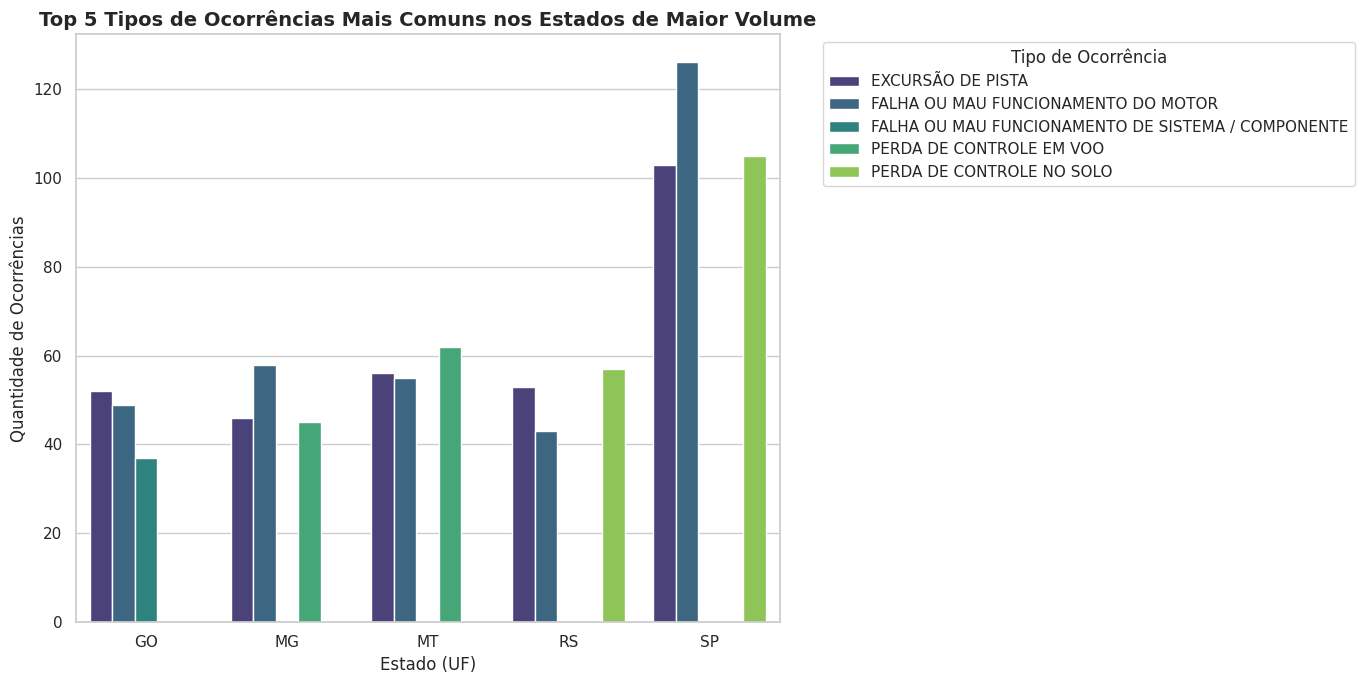

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

top5_estados = df['UF'].value_counts().head(5).index

df_top5 = df[df['UF'].isin(top5_estados)]
df_amostragem = df_top5.groupby(['UF', 'Descricao_do_Tipo']).size().reset_index(name='Quantidade')
df_amostragem = df_amostragem.groupby('UF').apply(lambda x: x.nlargest(3, 'Quantidade')).reset_index(drop=True)

plt.figure(figsize=(14, 7))
sns.barplot(data=df_amostragem, x='UF', y='Quantidade', hue='Descricao_do_Tipo', palette='viridis')

plt.title('Top 5 Tipos de Ocorrências Mais Comuns nos Estados de Maior Volume', fontsize=14, fontweight='bold')
plt.xlabel('Estado (UF)', fontsize=12)
plt.ylabel('Quantidade de Ocorrências', fontsize=12)
plt.legend(title='Tipo de Ocorrência', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


O gráfico de linhas expõe uma análise detalhada de séries temporais. Pode-se ver que as regiões com mais acidentes a partir de 2011 é a região Sudeste (mais vôos comerciais/executivos) e a região Centro-Oeste (aviação agrícola).

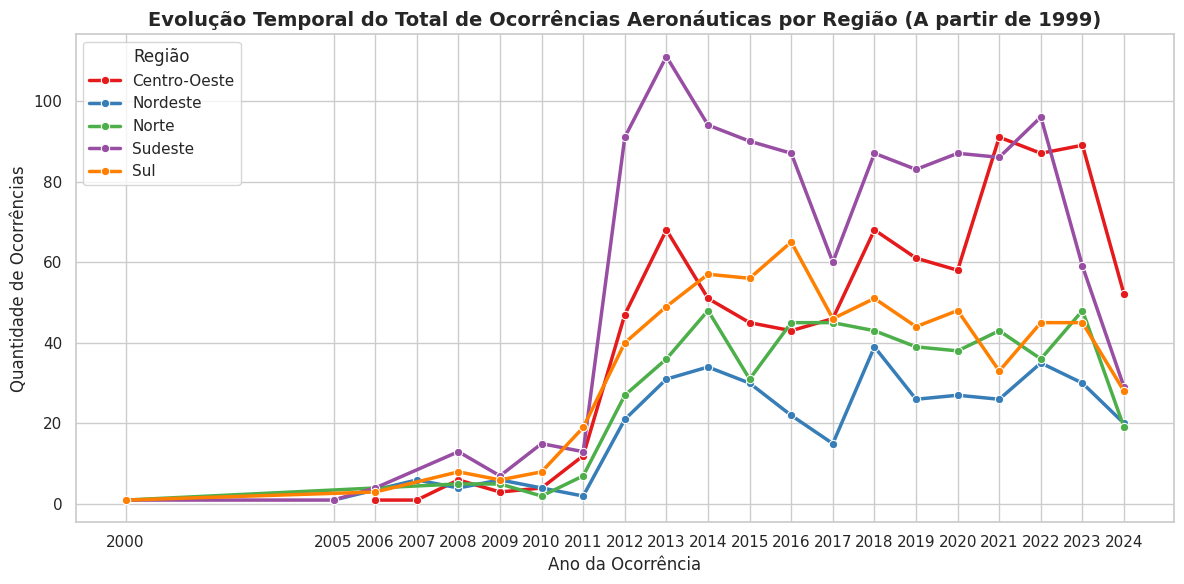

In [ ]:
df_regiao_ano = df.groupby(['Regiao', 'Ano']).size().reset_index(name='Total_Ocorrencias')

df_filtrado = df_regiao_ano[df_regiao_ano['Ano'] >= 1999]

plt.figure(figsize=(12, 6))

sns.lineplot(data=df_filtrado, x='Ano', y='Total_Ocorrencias', hue='Regiao', marker='o', linewidth=2.5, palette='Set1')

plt.title('Evolução Temporal do Total de Ocorrências Aeronáuticas por Região (A partir de 1999)', fontsize=14, fontweight='bold')
plt.xlabel('Ano da Ocorrência', fontsize=12)
plt.ylabel('Quantidade de Ocorrências', fontsize=12)

plt.xticks(sorted(df_filtrado['Ano'].unique()))

plt.legend(title='Região')
plt.tight_layout()
plt.show()


Na aviação, a fase de Pouso costuma registrar a maior quantidade absoluta de ocorrências (Gráfico da esquerda) devido à complexidade da manobra e aproximação com o solo. No entanto, o gráfico da direita frequentemente prova que fases como Em Rota ou Cruzeiro, embora tenham menos ocorrências registradas, respondem por um volume drasticamente maior de vítimas fatais devido à energia cinética e severidade do impacto quando algo falha em alta altitude.

/tmp/ipykernel_3036/4179974112.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fases_ocorrencias.values, y=fases_ocorrencias.index, ax=axes[0], palette='Blues_r')
/tmp/ipykernel_3036/4179974112.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fatalidades_por_fase.values, y=fatalidades_por_fase.index, ax=axes[1], palette='Oranges_r')


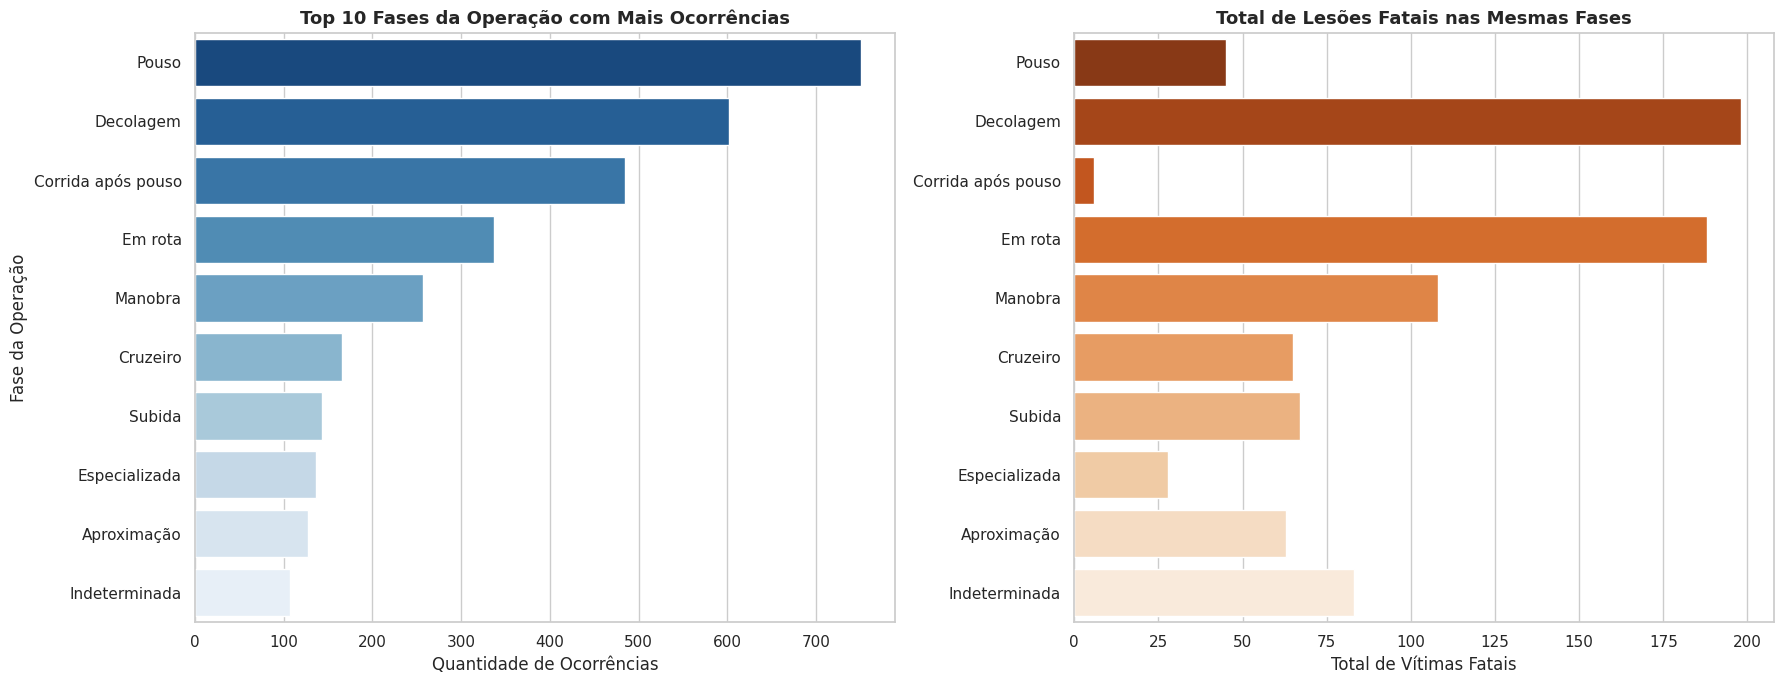

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

fases_ocorrencias = df['Fase_da_Operacao'].value_counts().head(10)
sns.barplot(x=fases_ocorrencias.values, y=fases_ocorrencias.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Fases da Operação com Mais Ocorrências', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Quantidade de Ocorrências')
axes[0].set_ylabel('Fase da Operação')

fatalidades_por_fase = df.groupby('Fase_da_Operacao')['Total_Lesoes_Fatais'].sum().loc[fases_ocorrencias.index]
sns.barplot(x=fatalidades_por_fase.values, y=fatalidades_por_fase.index, ax=axes[1], palette='Oranges_r')
axes[1].set_title('Total de Lesões Fatais nas Mesmas Fases', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total de Vítimas Fatais')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

O Mapa de Calor (Heatmap) converte números brutos em estímulos visuais de intensidade. Por exemplo, a categoria TPP (Privada) sofre massivamente com "Perda de Controle em Voo", enquanto outra categoria sofre muito mais com "Excursão de Pista", direcionando políticas específicas de treinamento para cada nicho.

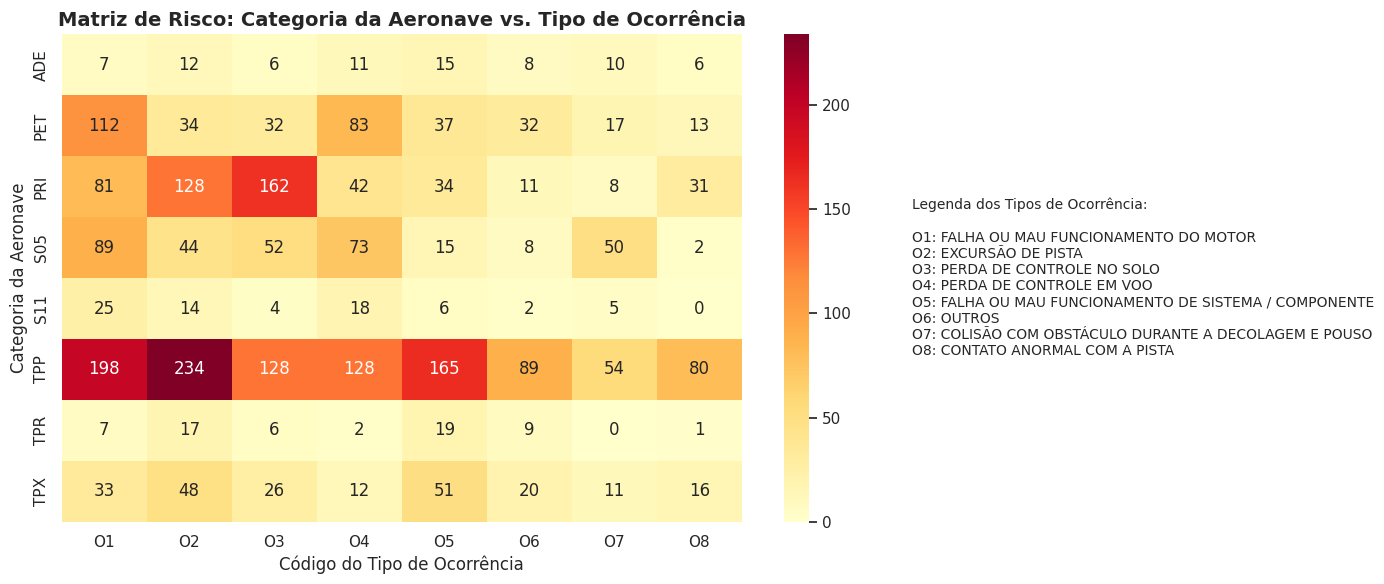

In [ ]:
top_categorias = df['Categoria_da_Aeronave'].value_counts().head(8).index
top_tipos_ocorrencia = df['Descricao_do_Tipo'].value_counts().head(8).index

df_pivot = df[
    df['Categoria_da_Aeronave'].isin(top_categorias)
    & df['Descricao_do_Tipo'].isin(top_tipos_ocorrencia)
].copy()

mapeamento_tipos = {
    tipo: f'O{i+1}' for i, tipo in enumerate(top_tipos_ocorrencia)
}
df_pivot['Tipo_Curto'] = df_pivot['Descricao_do_Tipo'].map(mapeamento_tipos)

tabela_cruzada = pd.crosstab(
    df_pivot['Categoria_da_Aeronave'], df_pivot['Tipo_Curto']
)

colunas_ordenadas = [f'O{i+1}' for i in range(len(top_tipos_ocorrencia))]
tabela_cruzada = tabela_cruzada.reindex(columns=colunas_ordenadas)

fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(tabela_cruzada, annot=True, fmt='d', cmap='YlOrRd', cbar=True, ax=ax)

plt.title(
    'Matriz de Risco: Categoria da Aeronave vs. Tipo de Ocorrência',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Código do Tipo de Ocorrência', fontsize=12)
plt.ylabel('Categoria da Aeronave', fontsize=12)

texto_legenda = '\n'.join(
    [f'{codigo}: {tipo}' for tipo, codigo in mapeamento_tipos.items()]
)

plt.text(
    1.25,
    0.5,
    f'Legenda dos Tipos de Ocorrência:\n\n{texto_legenda}',
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='center',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8),
)

plt.tight_layout()
plt.show()
